# 🎯 Daily Grand Lotto: Intelligence Analyzer
- **Model Health Diagnostic**: Performs a "Walk-Forward Validation" to test the AI's accuracy across 50 different historical points to see how it actually performs on unseen data.
- **Visual Intelligence Tracker**: Generates a Mean Absolute Error (MAE) graph to visually confirm if the AI's "intelligence" is improving (lower error) as the dataset grows over time.

📊 Generating Intelligence Graph (Last 50 Draws)...
Checking history point 930...
Checking history point 940...
Checking history point 950...
Checking history point 960...
Checking history point 970...


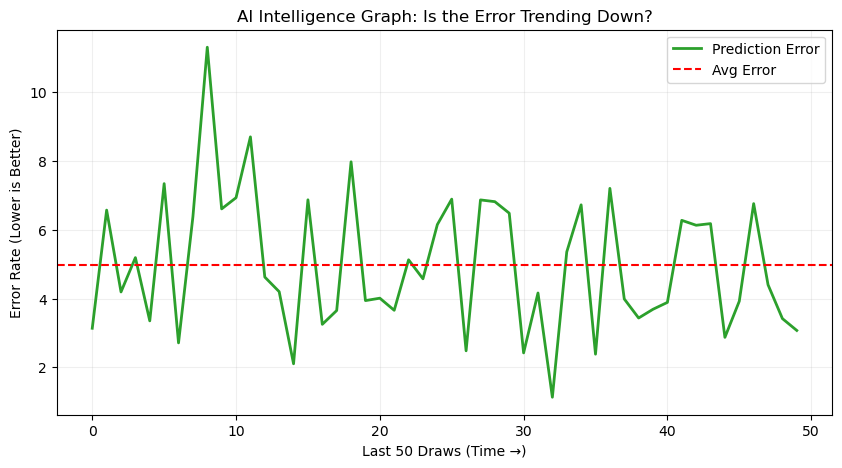

In [1]:
# === Daily Grand Lotto Intelligence Analyzer (GRAPH) ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error
from collections import Counter

# --- Load Data & Setup ---
df = pd.read_csv("daily_grand_results.csv").sort_values(by=["year", "month", "day"]).reset_index(drop=True)
number_cols = ['dn_1', 'dn_2', 'dn_3', 'dn_4', 'dn_5', 'grand_number']
main_cols = ['dn_1', 'dn_2', 'dn_3', 'dn_4', 'dn_5']

def get_features(df, idx):
    # (Simplified feature set for speed in the walk-forward loop)
    past = df.iloc[idx-3:idx][number_cols].values.flatten()
    return past

X, y = [], []
for i in range(3, len(df)):
    X.append(get_features(df, i))
    y.append(df.iloc[i][number_cols].values)
X, y = np.array(X), np.array(y)

# --- Walk-Forward Validation (Progressive Testing) ---
print("📊 Generating Intelligence Graph (Last 50 Draws)...")
errors = []
test_range = range(len(X)-50, len(X))
lite_model = MultiOutputRegressor(RandomForestRegressor(n_estimators=50, max_depth=5))

for i in test_range:
    if i % 10 == 0: print(f"Checking history point {i}...")
    lite_model.fit(X[:i], y[:i])
    pred = lite_model.predict(X[i:i+1])
    errors.append(mean_absolute_error(y[i:i+1], pred))

# --- Plotting ---
plt.figure(figsize=(10, 5))
plt.plot(errors, label='Prediction Error', color='#2ca02c', linewidth=2)
plt.axhline(y=np.mean(errors), color='r', linestyle='--', label='Avg Error')
plt.title('AI Intelligence Graph: Is the Error Trending Down?')
plt.xlabel('Last 50 Draws (Time →)')
plt.ylabel('Error Rate (Lower is Better)')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()